# Project 1.2 — Sound Classification using Valence & Arousal

In this notebook, we classify sound samples into four affective classes using the preprocessed **EmoSounds** and **IADSED** datasets.

1. Load the preprocessed datasets.
2. Map arousal and valence, then create Classes 1–4.
3. Save `final_emosounds.csv` and `final_iadsed.csv`.
4. Split each dataset into Train / Validation / Test = 60% / 20% / 20%.
5. Train three classification models.
6. Run 5-fold cross-validation and small hyperparameter searches on Train+Validation.
7. Compare with/without feature selection and balanced/imbalanced training.
8. Evaluate Accuracy and Macro F1 on Train+Validation and Test.
9. Show a confusion matrix for the best model on each dataset.

**Models:** Logistic Regression, Decision Tree, and K-Nearest Neighbors (KNN)  
**Feature selection:** SelectKBest with ANOVA F-score (`f_classif`)  
**Balancing:** Random oversampling (`RandomOverSampler`)

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import *
from sklearn.feature_selection import *
from sklearn.metrics import *

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

seed = 42
np.random.seed(seed)

## 1. Load the preprocessed datasets

In [21]:
def load_and_describe(path, name):
    df = pd.read_csv(path)
    print(f"{name}: {df.shape[0]} rows x {df.shape[1]} columns")
    print(f"Missing values: {df.isna().sum().sum()}")
    display(df.head())
    return df

emosounds = load_and_describe("EmoSounds_preprocessed.csv", "EmoSounds")
iadsed = load_and_describe("IADSED_preprocessed.csv", "IADSED")

EmoSounds: 600 rows x 70 columns
Missing values: 0


,arousal,valence,dynamics_rms_mean,dynamics_rms_std,pitch_pitch_mean,rhythm_attacktime_mean,rhythm_eventdensity_mean,rhythm_fluctuationmax_peakposmean,rhythm_pulseclarity_mean,rhythm_tempo_mean,...,timbre_lowenergy_mean,timbre_lowenergy_std,timbre_spectralflux_mean,timbre_spectralflux_std,tonal_hcdf_mean,tonal_hcdf_std,tonal_keyclarity_mean,tonal_keyclarity_std,tonal_mode_mean,tonal_mode_std
0,-0.518549,0.302556,0.013444,0.005903,375.990904,0.016346,1.145663,2.833503,0.136728,105.799224,...,5.415367,1.558017,10.204444,5.785453,0.244838,0.321193,0.457834,0.171750,-0.043605,0.068892
1,-0.929101,0.564716,0.011291,0.008784,855.112001,0.016366,2.127660,2.382534,0.156985,103.708910,...,4.652187,0.537740,9.799859,8.441237,0.629594,0.341241,0.440244,0.132387,-0.023940,0.098591
2,-0.940643,0.345425,0.000291,0.000261,494.090737,0.045209,1.800327,3.222729,0.284216,107.807879,...,5.317143,1.175990,0.310226,0.342690,0.451562,0.433910,0.416266,0.162932,-0.032507,0.094219
3,0.475680,0.193735,0.052846,0.028216,739.893910,0.020400,3.600655,3.233480,0.471585,162.728967,...,4.998831,1.429992,45.529733,29.307053,0.337036,0.215957,0.465368,0.129338,-0.031692,0.096302
4,0.901072,0.429514,0.087529,0.020352,630.302807,0.015339,3.764321,2.374726,0.114023,134.892943,...,4.937357,1.028468,67.812560,16.124870,0.195859,0.101366,0.576344,0.150061,-0.086635,0.111011


IADSED: 927 rows x 70 columns
Missing values: 0


,arousal,valence,dynamics_rms_mean,dynamics_rms_std,rhythm_attacktime_mean,rhythm_tempo_mean,rhythm_tempo_std,rhythm_pulseclarity_mean,rhythm_eventdensity_mean,rhythm_fluctuationmax_peakposmean,...,timbre_lowenergy_std,timbre_spectralflux_mean,timbre_spectralflux_std,pitch_pitch_mean,tonal_keyclarity_mean,tonal_keyclarity_std,tonal_mode_mean,tonal_mode_std,tonal_hcdf_mean,tonal_hcdf_std
0,4.181818,6.545455,0.095067,0.042815,0.030200,110.067705,0.898841,0.189203,2.166667,2.811672,...,1.422069,48.254947,24.727503,528.017203,0.432155,0.109549,-0.023553,0.080957,0.150785,0.130867
1,6.181818,3.227273,0.077893,0.039497,0.023715,115.703505,34.716839,0.145227,2.666667,2.190979,...,2.560911,71.886219,35.961220,625.613178,0.529449,0.150595,-0.019567,0.117713,0.268396,0.130745
2,5.227273,4.227273,0.069022,0.038171,0.038203,138.400170,12.529529,0.276840,4.500000,2.730568,...,2.168929,49.664474,28.268124,550.618550,0.454158,0.162282,-0.025239,0.038950,0.108528,0.105093
3,5.500000,4.500000,0.081225,0.048385,0.025925,116.451296,33.940893,0.182047,3.166667,2.502066,...,2.323706,59.662149,35.983242,555.333945,0.622735,0.088611,-0.055778,0.078180,0.169863,0.099310
4,6.541667,4.208333,0.092900,0.023437,0.033500,126.061062,16.580905,0.240607,4.833333,2.926762,...,1.294244,67.776311,17.871596,489.432139,0.458862,0.119900,0.017167,0.104018,0.169086,0.090438


## 2. Map arousal/valence and create the target classes

The class definitions are:

- **Class 1:** positive arousal, positive valence
- **Class 2:** positive arousal, negative valence
- **Class 3:** negative arousal, negative valence
- **Class 4:** negative arousal, positive valence

### Mapping

- EmoSounds is already on approximately `[-1, 1]`, so its arousal and valence values are kept as-is.
- IADSED is on a `1–9` scale, so each target is mapped to `[-1, 1]` using:

$$x_{\text{mapped}} = \frac{x - 5}{4}$$

This maps `1 -> -1`, `5 -> 0`, and `9 -> 1`.

For the few values that map to exactly `0`, we treat `0` as the non-negative/positive side so that every sample receives one of the four required classes.

In [22]:
def add_target_class(df, dataset_name):
    out = df.copy()
    if dataset_name == "EmoSounds":
        out["arousal_mapped"] = out["arousal"]
        out["valence_mapped"] = out["valence"]
    elif dataset_name == "IADSED":
        out["arousal_mapped"] = (out["arousal"] - 5) / 4
        out["valence_mapped"] = (out["valence"] - 5) / 4
    else:
        raise ValueError("Unknown dataset name")
    a = out["arousal_mapped"]
    v = out["valence_mapped"]
    conditions = [
        (a >= 0) & (v >= 0),  # Class 1
        (a >= 0) & (v < 0),   # Class 2
        (a < 0) & (v < 0),    # Class 3
        (a < 0) & (v >= 0),   # Class 4
    ]

    out["target_class"] = np.select(conditions, [1, 2, 3, 4], default=np.nan)
    out["target_class"] = out["target_class"].astype(int)
    return out


final_emosounds = add_target_class(emosounds, "EmoSounds")
final_iadsed = add_target_class(iadsed, "IADSED")

In [23]:
def show_class_counts(df, name):
    counts = df["target_class"].value_counts().sort_index()
    print(name)
    display(counts.rename("count").to_frame().head())
    return counts

emo_counts = show_class_counts(final_emosounds, "EmoSounds class distribution")
iad_counts = show_class_counts(final_iadsed, "IADSED class distribution")

EmoSounds class distribution


,count
1,62
2,232
3,101
4,205


IADSED class distribution


,count
1,164
2,482
3,130
4,151


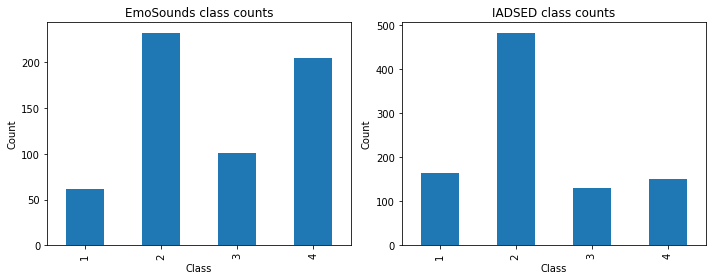

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

emo_counts.plot(kind="bar", ax=axes[0], title="EmoSounds class counts")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

iad_counts.plot(kind="bar", ax=axes[1], title="IADSED class counts")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Save the final datasets

In [25]:
final_emosounds.to_csv("final_emosounds.csv", index=False)
final_iadsed.to_csv("final_iadsed.csv", index=False)

print("Saved final_emosounds.csv")
print("Saved final_iadsed.csv")

Saved final_emosounds.csv
Saved final_iadsed.csv


## 3. Prepare features and make the 60/20/20 split

Arousal, valence, and the mapped target columns are not used as model inputs. The split is divided so that the class proportions stay similar in each subset.

After creating the required 60/20/20 split, the Train and Validation sets are combined for the 5-fold cross-validation and hyperparameter tuning on Train+Validation.

In [26]:
TARGET_COLUMNS = ["arousal", "valence", "arousal_mapped", "valence_mapped", "target_class"]

def prepare_xy(df):
    dominance_cols = [c for c in df.columns if "dominance" in c.lower()]
    drop_cols = [c for c in TARGET_COLUMNS + dominance_cols if c in df.columns]
    X = df.drop(columns=drop_cols)
    y = df["target_class"]
    # Keep numeric audio features only
    X = X.select_dtypes(include=np.number)

    return X, y


def split_60_20_20(X, y):
    # 80% train+validation, 20% test
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=seed,
        stratify=y,
    )

    # split the 80% into 60% train and 20% validation 
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=0.25, random_state=seed, stratify=y_trainval)

    return {"X_train": X_train, "X_val": X_val, "X_trainval": X_trainval, "X_test": X_test,
        "y_train": y_train, "y_val": y_val, "y_trainval": y_trainval, "y_test": y_test}


emo_X, emo_y = prepare_xy(final_emosounds)
iad_X, iad_y = prepare_xy(final_iadsed)

emo_split = split_60_20_20(emo_X, emo_y)
iad_split = split_60_20_20(iad_X, iad_y)

## 4. Balancing and feature selection

### Balancing
We use **random oversampling**, which duplicates minority-class training samples until all classes have the same count.

To avoid leakage, oversampling is placed inside the modeling pipeline. During 5-fold CV it is applied only to the training portion of each fold. The validation fold and final test set are never oversampled.

### Feature selection
We use `SelectKBest(f_classif)` and keep the top **20** audio features. The selector is also inside the pipeline, so it is fit only on the training data for each fold.

Each model is tested in all four required configurations:

1. Imbalanced, no feature selection
2. Imbalanced, with feature selection
3. Balanced, no feature selection
4. Balanced, with feature selection

In [27]:
def show_oversampling_example(split, name):
    sampler = RandomOverSampler(random_state=seed)
    _, y_resampled = sampler.fit_resample(split["X_trainval"], split["y_trainval"])
    before = split["y_trainval"].value_counts().sort_index()
    after = pd.Series(y_resampled).value_counts().sort_index()
    comparison = pd.DataFrame({"before_oversampling": before, "after_oversampling": after})
    print(name)
    display(comparison.head())

show_oversampling_example(emo_split, "EmoSounds")
show_oversampling_example(iad_split, "IADSED")

EmoSounds


,before_oversampling,after_oversampling
1,50,185
2,185,185
3,81,185
4,164,185


IADSED


,before_oversampling,after_oversampling
1,131,385
2,385,385
3,104,385
4,121,385


## 5. Models, 5-fold CV, and hyperparameter tuning

In [28]:
models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, random_state=seed),
        {
            "model__C": [0.1, 1.0, 10.0],
        },
    ),

    "Decision Tree": (
        DecisionTreeClassifier(random_state=seed),
        {
            "model__max_depth": [3, 5, None],
            "model__min_samples_split": [2, 5],
        },
    ),

    "KNN": (
        KNeighborsClassifier(),
        {
            "model__n_neighbors": [3, 5, 7],
            "model__weights": ["uniform", "distance"],
        },
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

- **Logistic Regression:** regularization strength `C`
- **Decision Tree:** tree depth and minimum samples needed to split
- **KNN:** number of neighbors and uniform vs. distance weighting

`GridSearchCV` selects hyperparameters using Macro F1, which gives equal importance to each class even when class sizes differ. After selecting the best settings, `GridSearchCV(refit=True)` automatically retrains that model on the full Train+Validation set.

In [29]:
def make_pipeline(model, use_feature_selection=False, use_balancing=False, n_features=20):
    selector = (
        SelectKBest(score_func=f_classif, k=n_features)
        if use_feature_selection
        else "passthrough"
    )

    sampler = (
        RandomOverSampler(random_state=seed)
        if use_balancing
        else "passthrough"
    )

    return Pipeline([
        ("scale", StandardScaler()),
        ("select", selector),
        ("balance", sampler),
        ("model", model),
    ])


def evaluate_predictions(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
    }


def run_experiments(split, dataset_name):
    rows = []
    fitted_searches = {}
    n_input_features = split["X_trainval"].shape[1]
    k_features = min(20, n_input_features)
    configurations = [(False, False), (True, False), (False, True), (True, True)]

    for model_name, (model, param_grid) in models.items():
        for use_fs, use_balancing in configurations:
            pipeline = make_pipeline(model=model, use_feature_selection=use_fs, 
                  use_balancing=use_balancing, n_features=k_features)
            search = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring="f1_macro", 
                  cv=cv, refit=True, n_jobs=-1, return_train_score=False)
            search.fit(split["X_trainval"], split["y_trainval"])
            trainval_pred = search.best_estimator_.predict(split["X_trainval"])
            test_pred = search.best_estimator_.predict(split["X_test"])
            trainval_metrics = evaluate_predictions(split["y_trainval"], trainval_pred)
            test_metrics = evaluate_predictions(split["y_test"], test_pred)
            key = (model_name, use_fs, use_balancing)
            fitted_searches[key] = search
            rows.append({
                "Dataset": dataset_name, "Model": model_name,
                "Feature Selection": "Yes" if use_fs else "No",
                "Balanced": "Yes" if use_balancing else "No",
                "Selected Feature Count": k_features if use_fs else n_input_features,
                "Best Params": search.best_params_,
                "CV Macro F1": search.best_score_,
                "Train+Val Accuracy": trainval_metrics["accuracy"],
                "Train+Val Macro F1": trainval_metrics["macro_f1"],
                "Test Accuracy": test_metrics["accuracy"],
                "Test Macro F1": test_metrics["macro_f1"],
            })

    results = pd.DataFrame(rows)
    return results, fitted_searches

### Run all experiments on EmoSounds

In [30]:
emo_results, emo_searches = run_experiments(emo_split, "EmoSounds")
emo_results.sort_values(["Test Macro F1", "Test Accuracy"], ascending=False).reset_index(drop=True).head()

,Dataset,Model,Feature Selection,Balanced,Selected Feature Count,Best Params,CV Macro F1,Train+Val Accuracy,Train+Val Macro F1,Test Accuracy,Test Macro F1
0,EmoSounds,KNN,No,No,68,"{'model__n_neighbors': 7, 'model__weights': 'u...",0.502025,0.697917,0.621367,0.691667,0.596178
1,EmoSounds,KNN,Yes,No,20,"{'model__n_neighbors': 7, 'model__weights': 'u...",0.525745,0.710417,0.630442,0.683333,0.584466
2,EmoSounds,Logistic Regression,Yes,Yes,20,{'model__C': 10.0},0.561176,0.654167,0.615591,0.675000,0.580054
3,EmoSounds,Logistic Regression,Yes,No,20,{'model__C': 10.0},0.532452,0.710417,0.597784,0.750000,0.569228
4,EmoSounds,Logistic Regression,No,No,68,{'model__C': 1.0},0.532659,0.822917,0.765661,0.700000,0.565564


### Run all experiments on IADSED

In [31]:
iad_results, iad_searches = run_experiments(iad_split, "IADSED")
iad_results.sort_values(["Test Macro F1", "Test Accuracy"], ascending=False).reset_index(drop=True).head()

,Dataset,Model,Feature Selection,Balanced,Selected Feature Count,Best Params,CV Macro F1,Train+Val Accuracy,Train+Val Macro F1,Test Accuracy,Test Macro F1
0,IADSED,KNN,No,No,68,"{'model__n_neighbors': 3, 'model__weights': 'd...",0.450104,1.000000,1.000000,0.623656,0.565984
1,IADSED,Logistic Regression,No,No,68,{'model__C': 1.0},0.526623,0.726046,0.666535,0.639785,0.558928
2,IADSED,Logistic Regression,Yes,Yes,20,{'model__C': 1.0},0.476203,0.520918,0.505845,0.553763,0.547365
3,IADSED,Logistic Regression,No,Yes,68,{'model__C': 10.0},0.494074,0.646424,0.634504,0.553763,0.531789
4,IADSED,KNN,No,Yes,68,"{'model__n_neighbors': 3, 'model__weights': 'd...",0.427038,1.000000,1.000000,0.553763,0.522797


## 6. Comparisons

In [32]:
all_results = pd.concat([emo_results, iad_results], ignore_index=True)
all_results.to_csv("p1_2_model_results.csv", index=False)
all_results.sort_values(["Dataset", "Test Macro F1"], ascending=[True, False]).reset_index(drop=True).head()

,Dataset,Model,Feature Selection,Balanced,Selected Feature Count,Best Params,CV Macro F1,Train+Val Accuracy,Train+Val Macro F1,Test Accuracy,Test Macro F1
0,EmoSounds,KNN,No,No,68,"{'model__n_neighbors': 7, 'model__weights': 'u...",0.502025,0.697917,0.621367,0.691667,0.596178
1,EmoSounds,KNN,Yes,No,20,"{'model__n_neighbors': 7, 'model__weights': 'u...",0.525745,0.710417,0.630442,0.683333,0.584466
2,EmoSounds,Logistic Regression,Yes,Yes,20,{'model__C': 10.0},0.561176,0.654167,0.615591,0.675000,0.580054
3,EmoSounds,Logistic Regression,Yes,No,20,{'model__C': 10.0},0.532452,0.710417,0.597784,0.750000,0.569228
4,EmoSounds,Logistic Regression,No,No,68,{'model__C': 1.0},0.532659,0.822917,0.765661,0.700000,0.565564


### Before vs. after feature selection

In [33]:
feature_selection_comparison = (all_results.groupby(["Dataset", "Model", "Feature Selection"], as_index=False)
    [["Test Accuracy", "Test Macro F1"]].mean())
feature_selection_comparison.head()

,Dataset,Model,Feature Selection,Test Accuracy,Test Macro F1
0,EmoSounds,Decision Tree,No,0.587500,0.461408
1,EmoSounds,Decision Tree,Yes,0.583333,0.460999
2,EmoSounds,KNN,No,0.633333,0.564571
3,EmoSounds,KNN,Yes,0.616667,0.553445
4,EmoSounds,Logistic Regression,No,0.683333,0.562809


### Balanced vs. imbalanced training

In [34]:
balancing_comparison = (all_results.groupby(["Dataset", "Model", "Balanced"], as_index=False)
    [["Test Accuracy", "Test Macro F1"]].mean())
balancing_comparison.head()

,Dataset,Model,Balanced,Test Accuracy,Test Macro F1
0,EmoSounds,Decision Tree,No,0.579167,0.427165
1,EmoSounds,Decision Tree,Yes,0.591667,0.495242
2,EmoSounds,KNN,No,0.687500,0.590322
3,EmoSounds,KNN,Yes,0.562500,0.527694
4,EmoSounds,Logistic Regression,No,0.725000,0.567396


### Average results across the four configurations

In [35]:
configuration_comparison = (all_results.groupby(["Dataset", "Feature Selection", "Balanced"], as_index=False)
    [["Test Accuracy", "Test Macro F1"]].mean().sort_values(["Dataset", "Test Macro F1"], ascending=[True, False]))
configuration_comparison.head()

,Dataset,Feature Selection,Balanced,Test Accuracy,Test Macro F1
1,EmoSounds,No,Yes,0.613889,0.538604
2,EmoSounds,Yes,No,0.672222,0.536000
3,EmoSounds,Yes,Yes,0.602778,0.523390
0,EmoSounds,No,No,0.655556,0.520589
4,IADSED,No,No,0.596774,0.527863


## 7. Best model and confusion matrix for each dataset

The best model/configuration is selected by its 5-fold CV Macro F1 score on Train+Validation, and then we show its test-set confusion matrix.

Best EmoSounds model by CV Macro F1
Model: Logistic Regression
Feature Selection: Yes
Balanced: Yes
Best Parameters: {'model__C': 10.0}
CV Macro F1: 0.5612
Test Accuracy: 0.6750
Test Macro F1: 0.5801


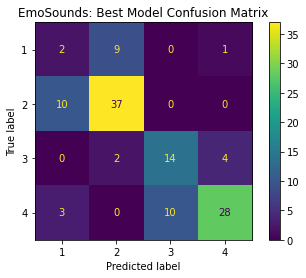

In [36]:
def show_best_model_and_confusion_matrix(results, searches, split, dataset_name):
    best_row = (results.sort_values("CV Macro F1", ascending=False).iloc[0])

    model_name = best_row["Model"]
    use_fs = best_row["Feature Selection"] == "Yes"
    use_balancing = best_row["Balanced"] == "Yes"

    search = searches[(model_name, use_fs, use_balancing)]
    best_estimator = search.best_estimator_
    test_pred = best_estimator.predict(split["X_test"])

    print(f"Best {dataset_name} model by CV Macro F1")
    print(f"Model: {model_name}")
    print(f"Feature Selection: {best_row['Feature Selection']}")
    print(f"Balanced: {best_row['Balanced']}")
    print(f"Best Parameters: {best_row['Best Params']}")
    print(f"CV Macro F1: {best_row['CV Macro F1']:.4f}")
    print(f"Test Accuracy: {best_row['Test Accuracy']:.4f}")
    print(f"Test Macro F1: {best_row['Test Macro F1']:.4f}")

    ConfusionMatrixDisplay.from_predictions(split["y_test"], test_pred, labels=[1, 2, 3, 4])
    plt.title(f"{dataset_name}: Best Model Confusion Matrix")
    plt.show()

    return best_row, best_estimator


best_emo_row, best_emo_model = show_best_model_and_confusion_matrix(emo_results, emo_searches, emo_split, "EmoSounds")

Best IADSED model by CV Macro F1
Model: Logistic Regression
Feature Selection: No
Balanced: No
Best Parameters: {'model__C': 1.0}
CV Macro F1: 0.5266
Test Accuracy: 0.6398
Test Macro F1: 0.5589


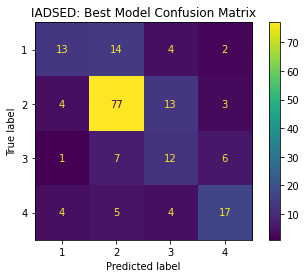

In [37]:
best_iad_row, best_iad_model = show_best_model_and_confusion_matrix(iad_results, iad_searches, iad_split, "IADSED")

### Selected features for the best models (when feature selection is used)

In [38]:
def selected_feature_names(best_row, best_model, X_columns):
    if best_row["Feature Selection"] != "Yes":
        return list(X_columns)

    selector = best_model.named_steps["select"]
    mask = selector.get_support()
    return list(X_columns[mask])


emo_selected = selected_feature_names(best_emo_row, best_emo_model, emo_split["X_trainval"].columns)

iad_selected = selected_feature_names(best_iad_row, best_iad_model, iad_split["X_trainval"].columns)

print("EmoSounds selected features:")
print(emo_selected)
print()
print("IADSED selected features:")
print(iad_selected)

EmoSounds selected features:
['dynamics_rms_mean', 'dynamics_rms_std', 'rhythm_fluctuationmax_peakposmean', 'spectral_centroid_std', 'spectral_flatness_mean', 'spectral_mfcc_std_10', 'spectral_mfcc_std_13', 'spectral_mfcc_std_4', 'spectral_mfcc_std_5', 'spectral_mfcc_std_6', 'spectral_mfcc_std_7', 'spectral_mfcc_std_8', 'spectral_mfcc_std_9', 'spectral_novelty_mean', 'spectral_rolloff85_std', 'spectral_rolloff95_mean', 'spectral_spread_mean', 'timbre_lowenergy_std', 'timbre_spectralflux_mean', 'timbre_spectralflux_std']

IADSED selected features:
['dynamics_rms_mean', 'dynamics_rms_std', 'rhythm_attacktime_mean', 'rhythm_tempo_mean', 'rhythm_tempo_std', 'rhythm_pulseclarity_mean', 'rhythm_eventdensity_mean', 'rhythm_fluctuationmax_peakposmean', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_brightness_mean', 'spectral_brightness_std', 'spectral_spread_mean', 'spectral_spread_std', 'spectral_skewness_mean', 'spectral_skewness_std', 'spectral_kurtosis_mean', 'spectral_kurto